# `AA Workshop 5` — Coding Challenge

Complete the tasks below to practice implementing regression modeling from `W5_Regression_Basics.ipynb`.

Guidelines:
- Work in order. Run each cell after editing with Shift+Enter.
- Keep answers short; focus on making things work.
- If a step fails, read the error and fix it.

By the end you will have exercised:
- running linear regressions with `scikit-learn` using a single or multiple features
- visualizing regression outputs
- comparing training error metrics

## Data

For all following tasks, you will work on the same dataset of ridehailing trips from New York City for a single day (August 1st, 2025). The provided dataset is a subset of the data published by the New York City Taxi & Limousine Commission, which is publicly available [here](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page). Load the data (which can be found in the `data`-folder). Then, restrict our sample to trips with a distance of up to 10 miles and a duration of up to 100 minutes. Finally, inspect the data.

In [13]:
# your code here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# load data
data = pd.read_csv('../data/ridehailing_NYC_20250801.csv')
display(data.head())
data.info()


,request_datetime,pickup_datetime,dropoff_datetime,trip_miles,trip_minutes,base_passenger_fare,provider
0,2025-08-01 00:07:01,2025-08-01 00:09:29,2025-08-01 00:22:28,1.5,13,44.43,uber
1,2025-08-01 00:31:28,2025-08-01 00:35:50,2025-08-01 00:46:56,2.1,11,22.20,uber
2,2025-08-01 00:53:16,2025-08-01 00:56:55,2025-08-01 01:18:05,3.0,21,24.81,uber
3,2025-08-01 00:52:57,2025-08-01 00:56:10,2025-08-01 01:02:18,1.3,6,15.15,uber
4,2025-08-01 00:06:10,2025-08-01 00:09:44,2025-08-01 00:26:07,8.3,16,22.84,uber


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 681399 entries, 0 to 681398
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   request_datetime     681399 non-null  object 
 1   pickup_datetime      681399 non-null  object 
 2   dropoff_datetime     681399 non-null  object 
 3   trip_miles           681399 non-null  float64
 4   trip_minutes         681399 non-null  int64  
 5   base_passenger_fare  681399 non-null  float64
 6   provider             681399 non-null  object 
dtypes: float64(2), int64(1), object(4)
memory usage: 36.4+ MB


In [14]:
# apply date time conversion
data['request_datetime'] = pd.to_datetime(data['request_datetime'])
data['pickup_datetime'] = pd.to_datetime(data['pickup_datetime'])
data['dropoff_datetime'] = pd.to_datetime(data['dropoff_datetime'])

# drop rows 
data.drop(data[data["trip_miles"] > 10].index, inplace=True)
data.drop(data[data["trip_minutes"] > 100].index, inplace=True)

In [15]:
data.describe(include='all')

,request_datetime,pickup_datetime,dropoff_datetime,trip_miles,trip_minutes,base_passenger_fare,provider
count,589053,589053,589053,589053.000000,589053.000000,589053.000000,589053
unique,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,NaN,NaN,NaN,NaN,uber
freq,NaN,NaN,NaN,NaN,NaN,NaN,418059
mean,2025-08-01 14:20:12.992847616,2025-08-01 14:24:41.526852608,2025-08-01 14:41:17.878041344,3.343068,16.606528,20.156269,NaN
min,2025-07-31 23:20:00,2025-08-01 00:00:00,2025-08-01 00:02:09,0.000000,0.000000,-8.370000,NaN
25%,2025-08-01 09:26:24,2025-08-01 09:30:16,2025-08-01 09:46:48,1.400000,9.000000,11.660000,NaN
50%,2025-08-01 15:11:35,2025-08-01 15:16:24,2025-08-01 15:35:24,2.600000,15.000000,17.050000,NaN
75%,2025-08-01 19:40:09,2025-08-01 19:44:13,2025-08-01 20:00:15,4.700000,22.000000,25.310000,NaN
max,2025-08-02 00:03:24,2025-08-01 23:59:59,2025-08-02 01:07:49,10.000000,99.000000,193.760000,NaN


In [16]:
data.drop(data[data["base_passenger_fare"] < 0].index, inplace=True)

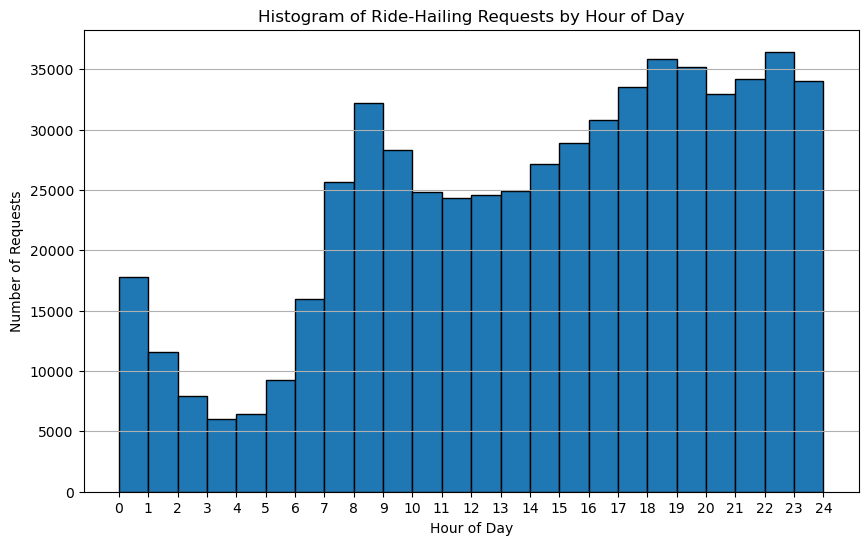

In [17]:
# plot histogram of request_datetime in hourly bins
plt.figure(figsize=(10,6))
plt.hist(data['request_datetime'].dt.hour, bins=24, range=(0,24), edgecolor='black')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Requests')
plt.title('Histogram of Ride-Hailing Requests by Hour of Day')
plt.xticks(range(0,25))
plt.grid(axis='y')
plt.show()

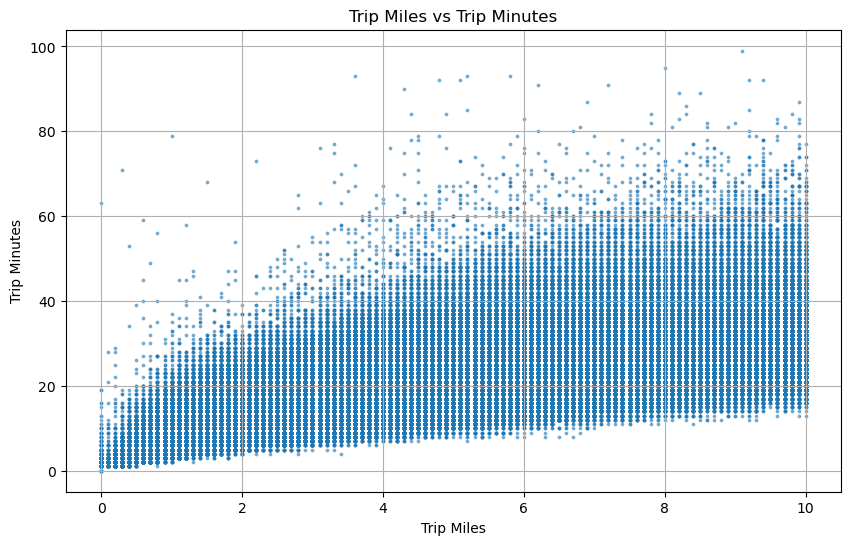

In [18]:
# plot trip_miles vs trip_minutes
plt.figure(figsize=(10,6))
plt.scatter(data['trip_miles'], data['trip_minutes'], alpha=0.5, s=3)
plt.xlabel('Trip Miles')
plt.ylabel('Trip Minutes')
plt.title('Trip Miles vs Trip Minutes')
plt.grid()
plt.show()  

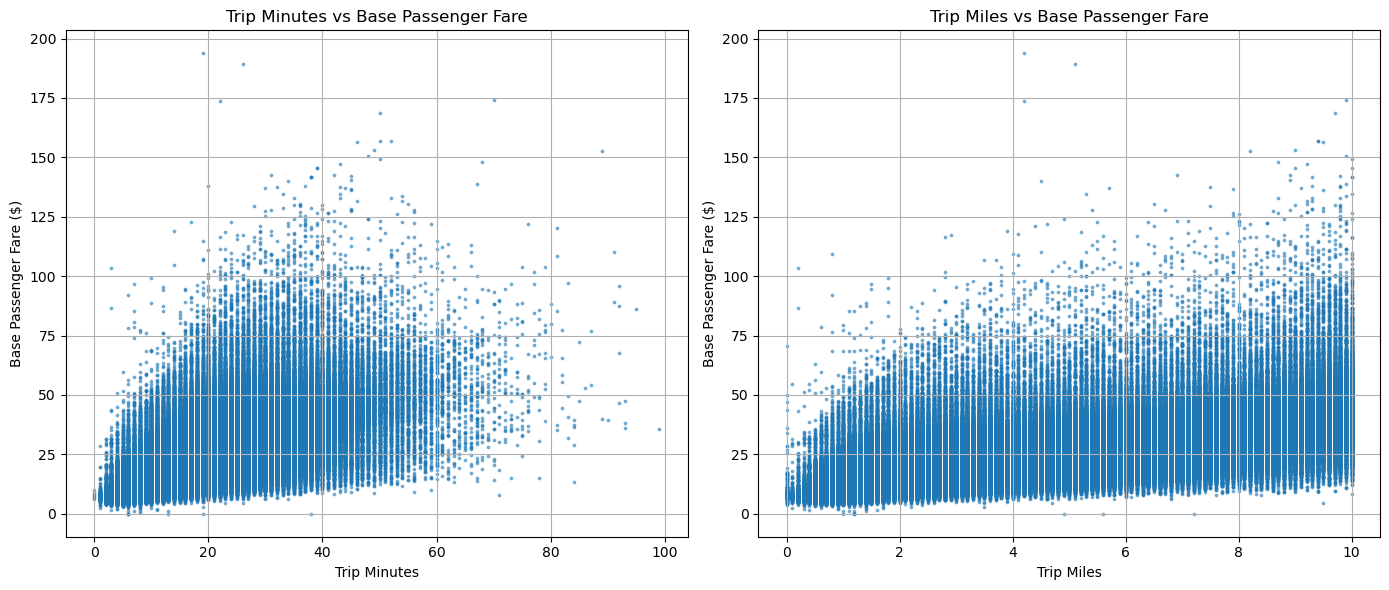

In [19]:

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# trip cost vs trip minutes
axes[0].scatter(data['trip_minutes'], data['base_passenger_fare'], alpha=0.5, s=3)
axes[0].set_xlabel('Trip Minutes')
axes[0].set_ylabel('Base Passenger Fare ($)')
axes[0].set_title('Trip Minutes vs Base Passenger Fare')
axes[0].grid()

# trip cost vs trip miles
axes[1].scatter(data['trip_miles'], data['base_passenger_fare'], alpha=0.5, s=3)
axes[1].set_xlabel('Trip Miles')
axes[1].set_ylabel('Base Passenger Fare ($)')
axes[1].set_title('Trip Miles vs Base Passenger Fare')
axes[1].grid()

plt.tight_layout()
plt.show()


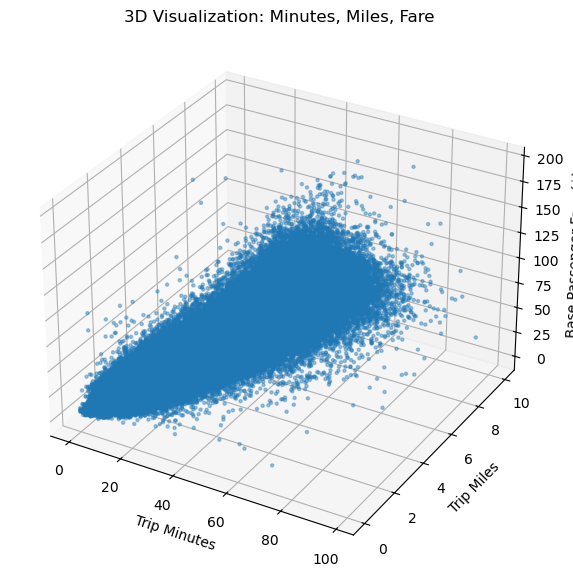

In [20]:
from mpl_toolkits.mplot3d import Axes3D  # nötig für 3D-Projektion

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# 3D-Scatterplot
ax.scatter(
    data['trip_minutes'],
    data['trip_miles'],
    data['base_passenger_fare'],
    alpha=0.4,
    s=5
)

ax.set_xlabel('Trip Minutes')
ax.set_ylabel('Trip Miles')
ax.set_zlabel('Base Passenger Fare ($)')
ax.set_title('3D Visualization: Minutes, Miles, Fare')

plt.show()


## Task 1 - Predicting Ridehailing Fares in NYC

Use `scikit-learn` to run a linear regression to predict the `base_passenger_fare` based on `trip_miles`. Then, generate a scatter plot of the observed and predicted values.

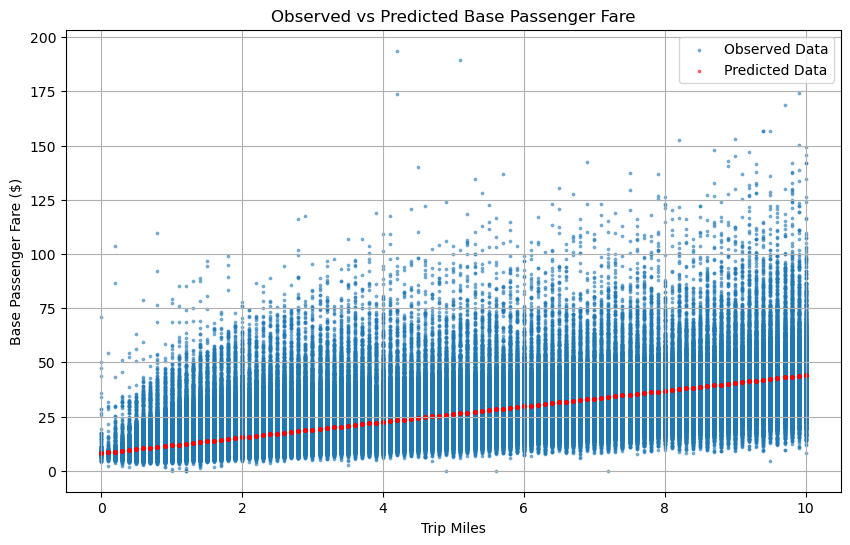

In [21]:
# your code here

from sklearn.linear_model import LinearRegression

X = data[['trip_miles']] # Feature muss 2D sein
y = data['base_passenger_fare'] # Zielvariable

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# Scatterplot: Beobachtete vs. vorhergesagte Werte
plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.5, s=3, label='Observed Data')
plt.scatter(X, y_pred, color='red', alpha=0.5, s=3, label='Predicted Data')
plt.xlabel('Trip Miles')
plt.ylabel('Base Passenger Fare ($)')
plt.title('Observed vs Predicted Base Passenger Fare')
plt.legend()
plt.grid()
plt.show()


## Task 2 - Distance or Duration?

Which feature is the better predictor of the fare: distance or duration? Compare the mean absolute error on the training set of regression models using `trip_miles` and `trip_minutes` as single predictors, respectively.

In [29]:
# your code here
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LinearRegression

# model based on trip_miles
X_miles = data[['trip_miles']] # Feature muss 2D sein
y = data['base_passenger_fare'] # Zielvariable
model_miles = LinearRegression()
model_miles.fit(X, y)
y_pred_miles = model_miles.predict(X)
mae_miles = mean_absolute_error(y, y_pred_miles)
print(f'Mean Absolute Error (Trip Miles Model): ${mae_miles:.2f}')
print("Intercept (Achsenabschnitt):", model_miles.intercept_)
print("Coefficients (Steigungen):", model_miles.coef_)

# model based on trip_minutes
X_minutes = data[['trip_minutes']] # Feature muss 2D sein
model_minutes = LinearRegression()
model_minutes.fit(X_minutes, y)
y_pred_minutes = model_minutes.predict(X_minutes)
mae_minutes = mean_absolute_error(y, y_pred_minutes)
print(f'Mean Absolute Error (Trip Minutes Model): ${mae_minutes:.2f}')
print("Intercept (Achsenabschnitt):", model_minutes.intercept_)
print("Coefficients (Steigungen):", model_minutes.coef_)

# model based on both features
X_both = data[['trip_miles', 'trip_minutes']]
model_both = LinearRegression()
model_both.fit(X_both, y)
y_pred_both = model_both.predict(X_both) 
mae_both = mean_absolute_error(y, y_pred_both)
print(f'Mean Absolute Error (Both Features Model): ${mae_both:.2f}')
print("Intercept (Achsenabschnitt):", model_both.intercept_)
print("Coefficients (Steigungen):", model_both.coef_)

Mean Absolute Error (Trip Miles Model): $5.23
Intercept (Achsenabschnitt): 8.136701993497825
Coefficients (Steigungen): [3.59545122]
Mean Absolute Error (Trip Minutes Model): $4.96
Intercept (Achsenabschnitt): 4.801873528603712
Coefficients (Steigungen): [0.92462205]
Mean Absolute Error (Both Features Model): $4.44
Intercept (Achsenabschnitt): 4.600386735999759
Coefficients (Steigungen): [1.88157432 0.55797141]


## Task 3 - Uber vs. Lyft

Our dataset also contains information on the provider of each trip, namely Uber or Lyft. Can we use this feature to improve our predictions of the passenger fare? Run a regression using both `trip_minutes` and `provider` as features. Calculate the mean absolute error on the training set, and generate a scatter plot including the regression lines for each provider in different colors.

In [31]:
data["provider"].value_counts()

provider
uber    418051
lyft    170993
Name: count, dtype: int64

In [35]:
# Option 2: Nur eine neue Spalte (verhindert Multikollinearität)
data_encoded = pd.get_dummies(data, columns=['provider'], drop_first=False)
# Erzeugt nur eine Spalte, z.B. 'provider_Uber' (1=Uber, 0=Lyft)
display(data_encoded.head())

,request_datetime,pickup_datetime,dropoff_datetime,trip_miles,trip_minutes,base_passenger_fare,provider_lyft,provider_uber
0,2025-08-01 00:07:01,2025-08-01 00:09:29,2025-08-01 00:22:28,1.5,13,44.43,False,True
1,2025-08-01 00:31:28,2025-08-01 00:35:50,2025-08-01 00:46:56,2.1,11,22.20,False,True
2,2025-08-01 00:53:16,2025-08-01 00:56:55,2025-08-01 01:18:05,3.0,21,24.81,False,True
3,2025-08-01 00:52:57,2025-08-01 00:56:10,2025-08-01 01:02:18,1.3,6,15.15,False,True
4,2025-08-01 00:06:10,2025-08-01 00:09:44,2025-08-01 00:26:07,8.3,16,22.84,False,True


In [37]:
# Features: trip_minutes + encoded provider
X = data_encoded[['trip_minutes', 'provider_uber']]
y = data_encoded['base_passenger_fare']

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
mae = mean_absolute_error(y, y_pred)
print(f'MAE: ${mae:.2f}')
print("Intercept (Achsenabschnitt):", model.intercept_)
print("Coefficients (Steigungen):", model.coef_)

MAE: $4.96
Intercept (Achsenabschnitt): 4.52472976831012
Coefficients (Steigungen): [0.92473752 0.38780038]


In [38]:
# Features: trip_minutes + encoded provider
X = data_encoded[['trip_minutes', 'provider_uber', 'provider_lyft']]
y = data_encoded['base_passenger_fare']

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
mae = mean_absolute_error(y, y_pred)
print(f'MAE: ${mae:.2f}')
print("Intercept (Achsenabschnitt):", model.intercept_)
print("Coefficients (Steigungen):", model.coef_)

# ergibt das selbe Ergebnis wie oben, da provider_lyft redundant ist

MAE: $4.96
Intercept (Achsenabschnitt): 4.718629959586437
Coefficients (Steigungen): [ 0.92473752  0.19390019 -0.19390019]


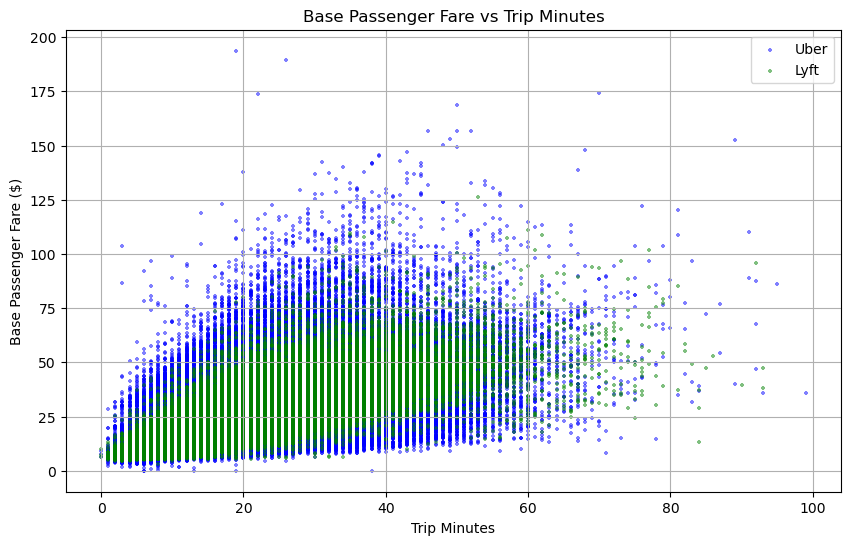

In [45]:
# scatterplot of uber vs lyft fares
plt.figure(figsize=(10,6))
plt.scatter(
    data_encoded[data_encoded['provider_uber'] == 1]['trip_minutes'],
    data_encoded[data_encoded['provider_uber'] == 1]['base_passenger_fare'],
    alpha=0.5,
    s=5, 
    color ='blue',
    label='Uber'
)
plt.scatter(
    data_encoded[data_encoded['provider_lyft'] == 1]['trip_minutes'],
    data_encoded[data_encoded['provider_lyft'] == 1]['base_passenger_fare'],
    alpha=0.5,
    s=5, 
    color ='green',
    label='Lyft'
)

plt.xlabel('Trip Minutes')
plt.ylabel('Base Passenger Fare ($)')
plt.title('Base Passenger Fare vs Trip Minutes')
plt.grid()
plt.legend()
plt.show()